### Computation of the Eigenvalue line

In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar

# Define H1d(k)
DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

def H1d(k):
    return 2 * np.sin(k) / k if k != 0 else 2.0  # handle k=0 safely


#def Trace
def trace_aq(k,mu):
    return - D_r -2 *k**2 - (mu * H1d(k)) / 2
def det_aq(k,mu,Pe):
    return 0.5 * k**2 * Pe**2 + (-D_r - k**2) * (-k**2 - mu * H1d(k) /2 )


# Define Lambda_nf1d(mu, k, Pe)
def Lambda_nf1d(mu, k, Pe):
    return -(k**2 + 0.5 * Pe**2 * (k**2 / (k**2 + D_r)) + (mu * H1d(k)) / 2)

# Range of Pe values
Pe_values = np.arange(0, 10,0.1)  # from 0 to 1 in steps of 0.1

results = []

for Pe in Pe_values:
    mus = np.arange(40, 800.1, 0.1)
    Lkc = []

    # For each mu, find the maximum of Lambda_nf1d(mu, k, Pe) for k in (1, 20)
    for mu in mus:
        res = minimize_scalar(lambda k: -Lambda_nf1d(mu, k, Pe), bounds=(1, 10), method='bounded')
        Lkc.append(-res.fun)  # negate back since we minimized the negative

    Lkc = np.array(Lkc)

    # Find the first mu where Lkc > 0
    positive_indices = np.where(Lkc > 0)[0]
    if len(positive_indices) > 0:
        mu_c = mus[positive_indices[0]]
    else:
        mu_c = np.nan  # if none positive, assign NaN

    results.append((Pe, mu_c))

# Display results
for Pe, mu_c in results:
    print(f"Pe = {Pe:.2f}, mu_c = {mu_c:.3f}")
np.savetxt("../Figures/results.txt", results, header="Pe  mu_c", fmt="%.4f")

In [1]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.fftpack import fft,ifft,fftfreq,fftshift,ifftshift
# Define H1d(k)
DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

def H1d(k):
    return 2 * np.sin(k) / k if k != 0 else 2.0  # handle k=0 safely


#def Trace
def trace_aq(k,mu):
    return - D_r -2 *k**2 - (mu * H1d(k)) / 2
def det_aq(k,mu,Pe):
    return 0.5 * k**2 * Pe**2 + (-D_r - k**2) * (-k**2 - mu * H1d(k) /2 )


# Define Lambda_nf1d(mu, k, Pe)
def Lambda_nf1d(mu, k, Pe):
    return -(k**2 + 0.5 * Pe**2 * (k**2 / (k**2 + D_r)) + (mu * H1d(k)) / 2)

def omega_hopf(k, mu, Pe):
    tr = trace_aq(k, mu)
    det = det_aq(k, mu, Pe)
    disc = det - (tr / 2)**2
    return np.sqrt(disc) if disc > 0 else 0.0
def find_kc(mu, Pe, kmin=1, kmax=8, Nk=2000):
    ks = np.linspace(kmin, kmax, Nk)
    tr_vals = np.array([trace_aq(k, mu) for k in ks])

    # Hopf occurs where trace crosses zero
    idx = np.argmin(np.abs(tr_vals))
    return ks[idx]
def propagation_velocity(mu, Pe):
    kc = find_kc(mu, Pe)
    omega_c = omega_hopf(kc, mu, Pe)
    return omega_c / kc, kc, omega_c

def find_kc_turing(mu, Pe, kmin=1, kmax=10, Nk=5000):
    ks = np.linspace(kmin, kmax, Nk)
    # nx = 1024
    # L = 1
    # ks = 2 * np.pi * fftfreq(nx, L / nx)*0.1

    det_vals = np.array([det_aq(k, mu, Pe) for k in ks])
    tr_vals  = np.array([trace_aq(k, mu) for k in ks])

    # Only allow trace < 0 (no Hopf)
    mask = tr_vals < 0

    if not np.any(mask):
        raise RuntimeError("No Turing-unstable mode found (trace always positive).")

    ks_valid = ks[mask]

    det_valid = det_vals[mask]
    # ks_valid = ks_valid[1:]
    # det_valid = det_valid[1:]

    # Find where determinant is closest to zero
    idx = np.argmin(np.abs(det_valid))

    return ks_valid[idx]

v, kc, omega_c = propagation_velocity(mu=177, Pe=7.5)

print("kc =", kc)
print("omega_c =", omega_c)
print("velocity =", v *COMP_RADIUS/TAU )

kc_turing = find_kc_turing(mu=84.2, Pe=0.0)

print("Turing kc =", kc_turing , 2*np.pi/kc_turing )

print("distance a =", COMP_RADIUS* 2*np.pi/kc_turing )



kc = 4.305652826413207
omega_c = 12.342765745688446
velocity = 0.0004299963179789334
Turing kc = 4.0768153630726145 1.5411993793224117
distance a = 0.15411993793224119


### Computation of critical Mu

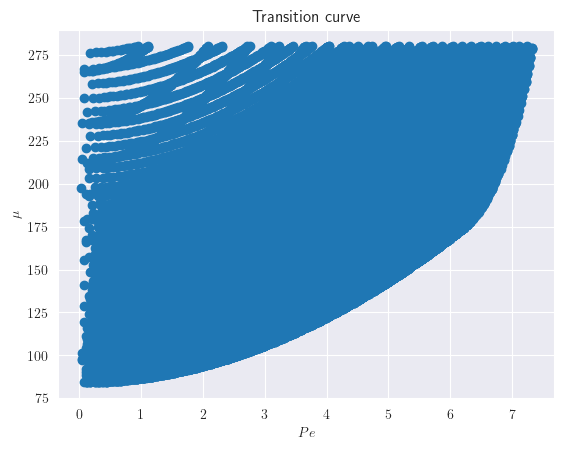

In [26]:
import numpy as np
from scipy.optimize import minimize_scalar
# Define H1d(k)
DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

def H1d(k):
    return 2 * np.sin(k) / k if k != 0 else 2.0  # handle k=0 safely


#def Trace
def trace_aq(k,mu):
    return - D_r -2 *k**2 - (mu * H1d(k)) / 2
def det_aq(k,mu,Pe):
    return 0.5 * k**2 * Pe**2 + (-D_r - k**2) * (-k**2 - mu * H1d(k) /2 )


# Define Lambda_nf1d(mu, k, Pe)
def Lambda_nf1d(mu, k, Pe):
    return -(k**2 + 0.5 * Pe**2 * (k**2 / (k**2 + D_r)) + (mu * H1d(k)) / 2)



k_values  = np.linspace(0.1, 10.0, 500)     # avoid k=0
mu_values = np.linspace(70, 280.0, 1000)
Pe_values = np.linspace(0.0, 10, 400)


transition_points = []

def mu_critical(k):
    return -2*(D_r + 2*k**2)/H1d(k)


transition_curve = []

for k in k_values:
    mu_max = mu_critical(k)
    for mu in mu_values[mu_values < mu_max]:
        det_vals = det_aq(k, mu, Pe_values)
        idx = np.where(np.diff(np.sign(det_vals)))[0]
        if len(idx):
            transition_curve.append((k, mu, Pe_values[idx[0]]))




import matplotlib.pyplot as plt

# unpack last two entries (mu, Pe)
mu_vals = [t[-2] for t in transition_curve]
Pe_vals = [t[-1] for t in transition_curve]

plt.figure()
plt.plot(Pe_vals,mu_vals, 'o')
plt.ylabel(r'$\mu$')
plt.xlabel(r'$Pe$')
plt.title('Transition curve')
plt.show()

# Stack columns: Pe   mu
data = np.column_stack((Pe_vals, mu_vals))

# Save to text file
np.savetxt(
    "../Figures/transition_curve_all.txt",
    data,
    header="Pe    mu",
    fmt="%.6e"
)

### DATA analysis of 1d Data

Group: FIELD_DATA
Dataset: FIELD_DATA/PX_0, Shape: (512,), Dtype: float64
Dataset: FIELD_DATA/PX_F, Shape: (512,), Dtype: float64
Dataset: FIELD_DATA/RHO_0, Shape: (512,), Dtype: float64
Dataset: FIELD_DATA/RHO_F, Shape: (512,), Dtype: float64
Group: metadata
Dataset: metadata/ADMENSIONAL_DR, Shape: (1,), Dtype: float64
Dataset: metadata/BIRTH_RATE, Shape: (1,), Dtype: float64
Dataset: metadata/DENSITY_SERIES, Shape: (1, 4001), Dtype: float64
Dataset: metadata/DIFF_R, Shape: (1,), Dtype: float64
Dataset: metadata/DIFF_T, Shape: (1,), Dtype: float64
Dataset: metadata/L, Shape: (1,), Dtype: float64
Dataset: metadata/NET_GROWTH_RATE, Shape: (1,), Dtype: float64
Dataset: metadata/PECLET, Shape: (1,), Dtype: float64
Dataset: metadata/POLARIZATION_INTEGRAL_SERIES, Shape: (1, 4001), Dtype: float64
Dataset: metadata/POLARIZATION_SERIES, Shape: (1, 4001), Dtype: float64
Dataset: metadata/RADIUS_KERNEL, Shape: (1,), Dtype: float64
Dataset: metadata/SIUMULATION_TIME, Shape: (1,), Dtype: float32
D

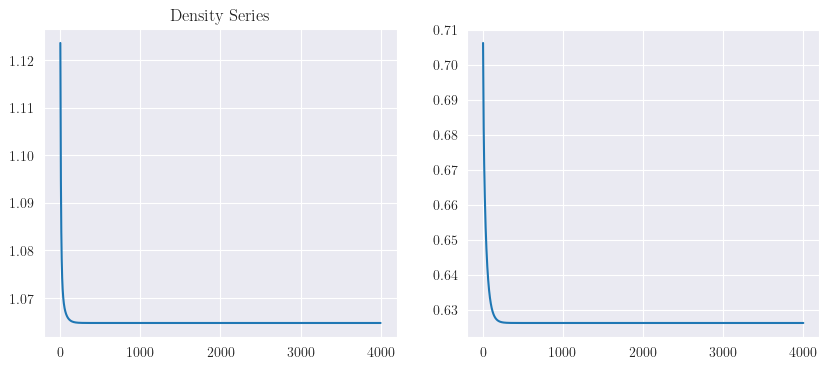

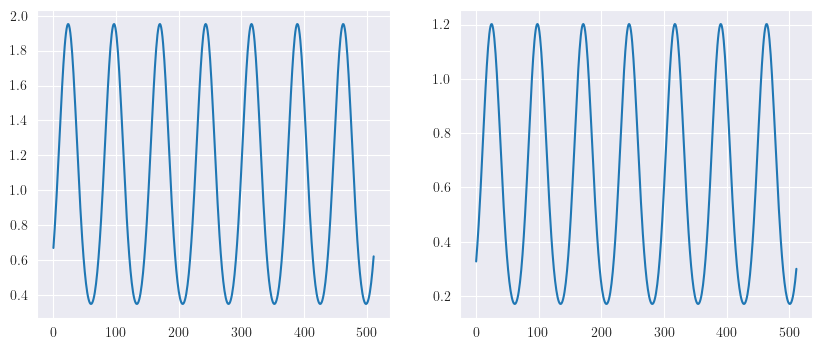

In [1]:
import h5py
import os, sys, re
from tqdm import tqdm
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rc

# Choose the font for the figure
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

### HDF5 File Inspection
def print_name(name, obj):
    """Function to print the name of groups and datasets in an HDF5 file."""
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}, Shape: {obj.shape}, Dtype: {obj.dtype}")


def print_hdf5_contents(file_path):
    """Function to open an HDF5 file and print its contents."""
    with h5py.File(file_path, 'r') as f:
        f.visititems(print_name)



mu , pe = 120.0, 4.5
# file_path = f'../Data/1d_v1/_PE{pe:.2f}_MU{mu:.2f}/DATA.h5'
file_path = f'../Data/turing_backward/_PE{pe:.2f}_MU{mu:.2f}/DATA.h5'

with h5py.File(file_path, 'r') as f:
    print_hdf5_contents(file_path)


    meta = f['FIELD_DATA']
    rhodata = meta['RHO_F'][:]
    pol = meta['PX_F'][:]


    meta2 = f['metadata']
    # Print metadata entries: name and value (or brief description for large objects)
    for name, obj in meta2.items():
        try:
            # For datasets, avoid loading extremely large arrays into memory
            if isinstance(obj, h5py.Dataset):
                if obj.size <= 1000:
                    print(f"{name}: {obj[()]}")
                else:
                    print(f"{name}: Dataset shape={obj.shape}, dtype={obj.dtype}, size={obj.size}")
            elif isinstance(obj, h5py.Group):
                print(f"{name}: Group")
            else:
                print(f"{name}: {type(obj)}")
        except Exception as e:
            # Fallback: print the object repr and the error
            print(f"{name}: <unable to read> ({e})")



    op = meta2['POLARIZATION_INTEGRAL_SERIES'][:].flatten()
    density = meta2['DENSITY_SERIES'][:].flatten()

    fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    ax1.plot(density)
    ax2.plot(op)
    ax1.set_title('Density Series')
    # ax2.set_title('Fourier Series')
    plt.show()
    plt.close()
    # fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    # ax1.plot(op_wei)
    # ax2.plot(op)
    # ax1.set_title('Polarization Weighted Density Series')
    # ax2.set_title('Polarization Series')
    # plt.show()
    # plt.close()
    #
    fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    ax1.plot(rhodata)
    ax2.plot(pol)
    plt.show()



In [44]:
import numpy as np
from scipy.fft import fft, fftfreq

def compute_critical_k(rho, dx):
    """
    Computes the dominant wavenumber k_c from a density array.

    Parameters:
    rho (ndarray): 1D array of density values at a specific time step.
    dx (float): The spatial step size (distance between grid points).

    Returns:
    k_c (float): The dominant wavenumber.
    """
    n = len(rho)

    # 1. Remove the mean to eliminate the DC component (k=0 peak)
    rho_detrended = rho - np.mean(rho)

    # 2. Compute the FFT
    rho_hat = fft(rho_detrended)

    # 3. Compute the Power Spectral Density (PSD)
    psd = np.abs(rho_hat)**2

    # 4. Get the corresponding frequencies
    # fftfreq returns cycles per unit distance (f)
    freqs = fftfreq(n, d=dx)

    # 5. Only look at the positive frequencies
    positive_indices = np.where(freqs > 0)
    psd = psd[positive_indices]
    freqs = freqs[positive_indices]

    # 6. Find the peak in the power spectrum
    peak_idx = np.argmax(psd)
    dominant_freq = freqs[peak_idx]

    # 7. Convert frequency (f) to wavenumber (k)
    # k = 2 * pi * f
    k_c = 2 * np.pi * dominant_freq

    return k_c


mu , pe = 180.0, 7
file_path = f'../Data/1d_v1/_PE{pe:.2f}_MU{mu:.2f}/DATA.h5'






dx =1/512

with h5py.File(file_path, 'r') as f:
    # print_hdf5_contents(file_path)


    meta = f['FIELD_DATA']
    rhodata = meta['RHO_F'][:]
    current_k = compute_critical_k(rhodata, dx)
print("Critical wavenumber k_c =", current_k*0.1)

Critical wavenumber k_c = 4.39822971502571


## Two Dimensional Data Analysis

In [1]:
import numpy as np
from scipy.special import j1  # Bessel function of the first kind, order 1
from scipy.optimize import minimize_scalar
# ---- Parameters ----
DIFF_T = 1e-4
COMP_RADIUS = 0.1
DIFF_R =0.01
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU


# ---- 2D kernel ----
def H2d(k):
    return 2 * j1(k) / k if k != 0 else 1.0  # limit k→0 → J1(k)/k ≈ 1/2 → 2*(1/2)=1

# ---- Lambda function ----
def Lambda_nf2d(mu, k, Pe):
    return -(k**2 + 0.5 * Pe**2 * (k**2 / (k**2 + D_r)) + (mu * H2d(k)) )

# ---- Range of Pe values ----
Pe_values = np.arange(0, 9.1, 0.1)
results = []

for Pe in Pe_values:
    mus = np.arange(170,500, 0.1)
    Lkc = []

    for mu in mus:
        res = minimize_scalar(lambda k: -Lambda_nf2d(mu, k, Pe), bounds=(1, 50), method='bounded')
        Lkc.append(-res.fun)  # maximize Lambda

    Lkc = np.array(Lkc)
    positive_indices = np.where(Lkc > 0)[0]

    mu_c = mus[positive_indices[0]] if len(positive_indices) > 0 else np.nan
    results.append((Pe, mu_c))

# Convert results to array for plotting or saving
results = np.array(results)

# Display results
for Pe, mu_c in results:
    print(f"Pe = {Pe:.2f}, mu_c = {mu_c:.3f}")
np.savetxt("../Figures/results2d.txt", results, header="Pe  mu_c", fmt="%.4f")

Pe = 0.00, mu_c = 185.200
Pe = 0.10, mu_c = 185.300
Pe = 0.20, mu_c = 185.400
Pe = 0.30, mu_c = 185.600
Pe = 0.40, mu_c = 185.900
Pe = 0.50, mu_c = 186.200
Pe = 0.60, mu_c = 186.600
Pe = 0.70, mu_c = 187.100
Pe = 0.80, mu_c = 187.700
Pe = 0.90, mu_c = 188.400
Pe = 1.00, mu_c = 189.100
Pe = 1.10, mu_c = 189.900
Pe = 1.20, mu_c = 190.800
Pe = 1.30, mu_c = 191.800
Pe = 1.40, mu_c = 192.800
Pe = 1.50, mu_c = 194.000
Pe = 1.60, mu_c = 195.200
Pe = 1.70, mu_c = 196.400
Pe = 1.80, mu_c = 197.800
Pe = 1.90, mu_c = 199.200
Pe = 2.00, mu_c = 200.700
Pe = 2.10, mu_c = 202.300
Pe = 2.20, mu_c = 203.900
Pe = 2.30, mu_c = 205.700
Pe = 2.40, mu_c = 207.500
Pe = 2.50, mu_c = 209.400
Pe = 2.60, mu_c = 211.300
Pe = 2.70, mu_c = 213.300
Pe = 2.80, mu_c = 215.400
Pe = 2.90, mu_c = 217.600
Pe = 3.00, mu_c = 219.900
Pe = 3.10, mu_c = 222.200
Pe = 3.20, mu_c = 224.600
Pe = 3.30, mu_c = 227.100
Pe = 3.40, mu_c = 229.600
Pe = 3.50, mu_c = 232.200
Pe = 3.60, mu_c = 234.900
Pe = 3.70, mu_c = 237.700
Pe = 3.80, m

Group: FIELD_DATA
Dataset: FIELD_DATA/PX_0, Shape: (128, 128), Dtype: float64
Dataset: FIELD_DATA/PX_F, Shape: (128, 128), Dtype: float64
Dataset: FIELD_DATA/Py_0, Shape: (128, 128), Dtype: float64
Dataset: FIELD_DATA/Py_F, Shape: (128, 128), Dtype: float64
Dataset: FIELD_DATA/RHO_0, Shape: (128, 128), Dtype: float64
Dataset: FIELD_DATA/RHO_F, Shape: (128, 128), Dtype: float64
Group: density_series
Dataset: density_series/DENSITY, Shape: (2000,), Dtype: float64
Dataset: density_series/S_MAX, Shape: (2000,), Dtype: float64
Group: metadata
Dataset: metadata/ADMENSIONAL_DR, Shape: (), Dtype: float64
Dataset: metadata/DEATH_RATE, Shape: (), Dtype: float64
Dataset: metadata/DIFF_R, Shape: (), Dtype: float64
Dataset: metadata/DIFF_T, Shape: (), Dtype: float64
Dataset: metadata/L, Shape: (), Dtype: float64
Dataset: metadata/LAST_SAVED_ITERATION, Shape: (), Dtype: int64
Dataset: metadata/NET_GROWTH_RATE, Shape: (), Dtype: float64
Dataset: metadata/PECLET, Shape: (), Dtype: float64
Dataset: met

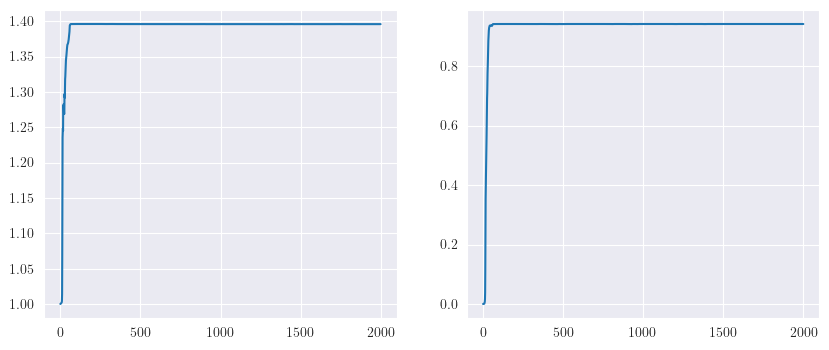

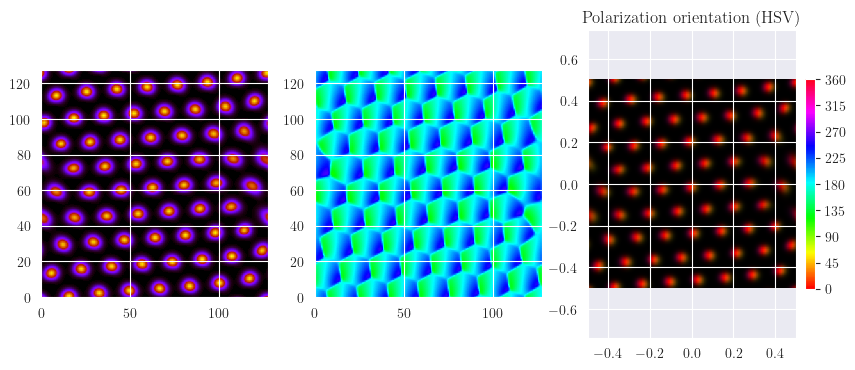

In [1]:
import h5py
import os, sys, re
from tqdm import tqdm
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rc

# Choose the font for the figure
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

### HDF5 File Inspection
def print_name(name, obj):
    """Function to print the name of groups and datasets in an HDF5 file."""
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}, Shape: {obj.shape}, Dtype: {obj.dtype}")


def print_hdf5_contents(file_path):
    """Function to open an HDF5 file and print its contents."""
    with h5py.File(file_path, 'r') as f:
        f.visititems(print_name)



mu , pe = 450.0, 8
file_path = f'../Data/2d_v1/_PE{pe:.2f}_MU{mu:.2f}/DATA.h5'
import matplotlib as mpl

def plot_pol_hue(Px,Py,bounds):
    fig, ax2 = plt.subplots(figsize=(10, 10))

    # --- Extent ---
    x_min, x_max = bounds[0], bounds[1]
    y_min, y_max = bounds[0], bounds[1]
    extent = [x_min, x_max, y_min, y_max]

    # --- Polarization magnitude and angle ---
    mag = np.sqrt(Px ** 2 + Py ** 2)
    mag_norm = mag / (mag.max() if mag.max() > 0 else 1.0)

    angle = (np.angle(Px + 1j * Py) % (2 * np.pi)) / (2 * np.pi)  # [0,1)

    # --- HSV image ---
    hsv = np.zeros((*mag.shape, 3))
    hsv[..., 0] = angle  # hue
    hsv[..., 1] = 1.0  # saturation
    hsv[..., 2] = mag_norm  # value

    rgb = mcolors.hsv_to_rgb(hsv)

    ax2.imshow(rgb, origin="lower", extent=extent)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    # ax2.set_title("Polarization direction & magnitude")

    # --- Correct cyclic colorbar (orientation only) ---
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(cmap="hsv", norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04)
    # cbar.set_label("Orientation (degrees)")
    cbar.set_ticks(np.linspace(0, 1, 9))
    cbar.set_ticklabels(np.linspace(0, 360, 9).astype(int))
    plt.show()
    plt.close()


bounds = np.array([-0.5, 0.5])  # Domain bounds


with h5py.File(file_path, 'r') as f:
    print_hdf5_contents(file_path)


    # meta = f['FIELD_DATA']
    # rhodata = meta['RHO_F'][:]
    # pol = meta['PX_F'][:]

    print('##############################################','\n \n','##############################################')
    meta2 = f['metadata']
    # Print metadata entries: name and value (or brief description for large objects)
    for name, obj in meta2.items():
        try:
            # For datasets, avoid loading extremely large arrays into memory
            if isinstance(obj, h5py.Dataset):
                if obj.size <= 1000:
                    print(f"{name}: {obj[()]}")
                else:
                    print(f"{name}: Dataset shape={obj.shape}, dtype={obj.dtype}, size={obj.size}")
            elif isinstance(obj, h5py.Group):
                print(f"{name}: Group")
            else:
                print(f"{name}: {type(obj)}")
        except Exception as e:
            # Fallback: print the object repr and the error
            print(f"{name}: <unable to read> ({e})")
    print('##############################################','\n \n','##############################################')

    grp1 = f['time_series']
    op = grp1['POLARIZATION'][:].flatten()
    grp3 = f['density_series']
    density = grp3['DENSITY'][:].flatten()
    fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    ax1.plot(density)
    ax2.plot(op)
    # ax1.set_title('Density Series')
    # # ax2.set_title('Fourier Series')
    plt.show()
    plt.close()
    fig , (ax1,ax2,ax3) = plt.subplots(1,3, figsize = (10,4))
    grp2 = f['FIELD_DATA']
    rhodata = grp2['RHO_F'][:]
    Px = grp2['PX_F'][:]
    Py = grp2['Py_F'][:]


    im = ax1.imshow(
        rhodata,
        origin="lower",
        cmap="gnuplot"
    )
    theta = np.arctan2(Py, Px)  # [-pi, pi)


    im = ax2.imshow(
        theta,
        origin="lower",
        cmap="hsv",
        vmin=-np.pi,
        vmax=np.pi
    )
    # plt.colorbar(
    #     im,
    #     ticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    #     label=r"$\theta$"
    # )
    plt.axis("equal")
    plt.title("Polarization orientation (HSV)")



    # --- Extent ---
    x_min, x_max = bounds[0], bounds[1]
    y_min, y_max = bounds[0], bounds[1]
    extent = [x_min, x_max, y_min, y_max]

    # --- Polarization magnitude and angle ---
    mag = np.sqrt(Px ** 2 + Py ** 2)
    mag_norm = mag / (mag.max() if mag.max() > 0 else 1.0)

    angle = (np.angle(Px + 1j * Py) % (2 * np.pi)) / (2 * np.pi)  # [0,1)

    # --- HSV image ---
    hsv = np.zeros((*mag.shape, 3))
    hsv[..., 0] = angle  # hue
    hsv[..., 1] = 1.0  # saturation
    hsv[..., 2] = mag_norm  # value

    rgb = mcolors.hsv_to_rgb(hsv)

    ax3.imshow(rgb, origin="lower", extent=extent)
    ax3.set_xlim(x_min, x_max)
    ax3.set_ylim(y_min, y_max)
    # ax2.set_title("Polarization direction & magnitude")

    # --- Correct cyclic colorbar (orientation only) ---
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(cmap="hsv", norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax3, fraction=0.046, pad=0.04)
    # cbar.set_label("Orientation (degrees)")
    cbar.set_ticks(np.linspace(0, 1, 9))
    cbar.set_ticklabels(np.linspace(0, 360, 9).astype(int))

    plt.show()
    plt.close()



225 383 158


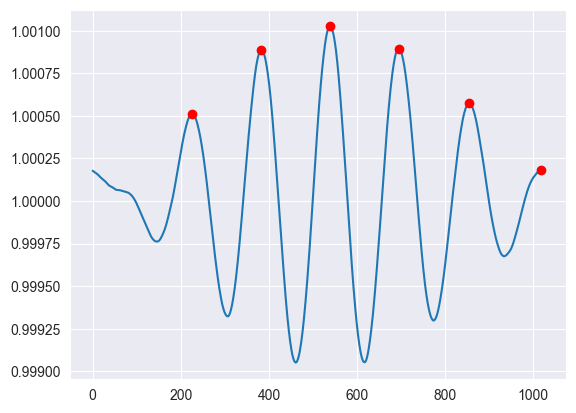

wave length of pattern = 0.154296875 In fourier space = 4.072140350982213


In [2]:
import numpy as np
import matplotlib.pyplot as plt


DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

rho0 = np.loadtxt("rho1.txt")
rho1 = np.loadtxt("rho10.txt")
# print(rho0)
plt.plot(rho1)


from scipy.ndimage import gaussian_filter1d

rho_smooth = gaussian_filter1d(rho1, sigma=2)

# first derivative
drho = np.gradient(rho_smooth)

# peaks where derivative changes sign
peaks = np.where((drho[:-1] > 0) & (drho[1:] < 0))[0]


plt.plot(peaks, rho1[peaks], "ro")

lambd = peaks[1] - peaks[0]
print(peaks[0], peaks[1], lambd)


plt.grid(True)
plt.show()

print(f'wave length of pattern = {lambd/1024}', f'In fourier space = {COMP_RADIUS* 2*np.pi/ (lambd/1024)}')


0.1787109375
100.0
velocity = 0.001787109375


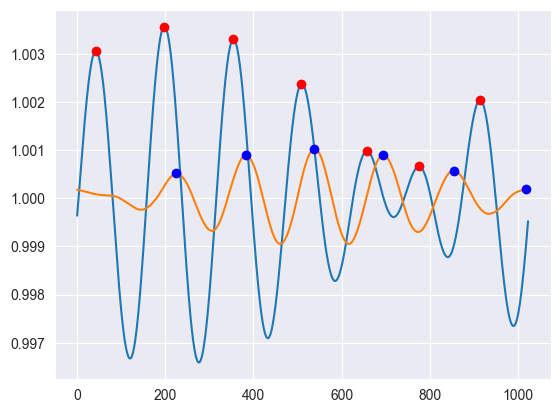

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

rho0 = np.loadtxt("rho1.txt")
rho1 = np.loadtxt("rho10.txt")
# print(rho0)
plt.plot(rho0)
plt.plot(rho1)

rho_smooth = gaussian_filter1d(rho0, sigma=2)
# first derivative
drho = np.gradient(rho_smooth)
# peaks where derivative changes sign
peaks = np.where((drho[:-1] > 0) & (drho[1:] < 0))[0]

plt.plot(peaks, rho0[peaks], "ro")


rho_smooth = gaussian_filter1d(rho1, sigma=2)
# first derivative
drho = np.gradient(rho_smooth)
# peaks where derivative changes sign
peaks1 = np.where((drho[:-1] > 0) & (drho[1:] < 0))[0]
plt.plot(peaks1, rho1[peaks1], "bo")

dt = 0.01
t = 10 *1000
x1 = peaks1[0]
x0 = peaks[0]
distance = (x1-x0)/1024
time = t * dt

print(distance)
print(time)

velocity = distance/time
print("velocity =", velocity)
